In [1]:
import os, re
import numpy as np
import warnings 
import pandas as pd 
import math

from typing import Dict, List, Optional

from datetime import datetime
import xarray as xr
import xskillscore as xs

from xcdat.dataset import open_dataset
from xcdat.bounds import create_bounds
from xcdat.dataset import open_mfdataset
from pathlib import Path
from typing import Sequence, Optional

import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from xarray.conventions import SerializationWarning
#warnings.filterwarnings("ignore", category=SerializationWarning)
warnings.filterwarnings("once", category=SerializationWarning)

/qfs/people/zhan391/.conda/envs/e3sm_analysis/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
def extract_exp_info(
    data_path: str,
    *,
    resolution: str = "ne30pg2_r05_IcoswISC30E3r5",
    machine: str = "compy",
    atm_subdir: str = "archive/post/atm/180x360_aave",
    lnd_subdir: str = "archive/post/lnd/180x360_aave",
) -> Dict[str, dict]:
    """
    Build a standardized experiment metadata dictionary for E3SM ensemble and DA runs.

    Returns a dict keyed by experiment name with:
      - nens, season, group_key
      - runs: {da|fc|wc} -> sub-run dict or None
      - default_run, key, period
    """

    exps = {
        "CTRL": {
            "nens": 1,
            "key": "ctrl",
            "da_run": None,
            "fc_run": {"compset": "F20TR", "name": "CTRL", "period": "201201-201212"},
            "wc_run": {"compset": "WCYCL20TR", "name": "CTRL", "period": "201201-201212"},
        },
        "CTRL10-S0": {
            "nens": 10,
            "key": "dart_en10",
            "da_run": {
                "compset": "F20TR", 
                "name": "CTRLEN10", 
                "period": 
                "201112-201112",
                "obs_diag": ["obs_seq", "obs_diag", "obs_common", "closest_member"],
            },
            "fc_run": {"compset": "F20TR", "name": "CTRLEN10_15day", "period": "201201-201202"},
            "wc_run": {"compset": "WCYCL20TR", "name": "CTRLEN10_15day", "period": "201201-201202"},
        },
        "CAPT10-S0": {
            "nens": 10,
            "key": "dart_en10",
            "da_run": None,
            "fc_run": {"compset": "F20TR", "name": "CAPTEN10_15day", "period": "201201-201202"},
            "wc_run": {"compset": "WCYCL20TR", "name": "CAPTEN10_15day", "period": "201201-201202"},
        },
        "DART10-S0": {
            "nens": 10,
            "key": "dart_en10",
            "da_run": {
                "compset": "F20TR", "name": "DARTEN10", "period": "201112-201112",
                "obs_diag": ["obs_seq", "obs_diag", "obs_common", "closest_member"],
            },
            "fc_run": None,
            "wc_run": None,
        },
        "DART20-S0": {
            "nens": 20,
            "key": "dart_en20",
            "da_run": {
                "compset": "F20TR", "name": "DARTEN20", "period": "201112-201112",
                "obs_diag": ["obs_seq", "obs_diag", "obs_common", "closest_member"],
            },
            "fc_run": {"compset": "F20TR", "name": "DARTEN20_15day", "period": "201201-201202"},
            "wc_run": {"compset": "WCYCL20TR", "name": "DARTEN20_15day", "period": "201201-201202"},
        },
        "DART40-S0": {
            "nens": 40,
            "key": "dart_en40",
            "da_run": {
                "compset": "F20TR", "name": "DARTEN40", "period": "201112-201112",
                "obs_diag": ["obs_seq", "obs_diag", "obs_common", "closest_member"],
            },
            "fc_run": {"compset": "F20TR", "name": "DARTEN40_15day", "period": "201201-201202"},
            "wc_run": {"compset": "WCYCL20TR", "name": "DARTEN40_15day", "period": "201201-201202"},
        },
        "CAM80-S0": {
            "nens": 80,
            "key": "dart_en80",
            "da_run": {
                "run_id": "f.e21.FHIST_BGC.f09_025.CAM6assim.011", "name": "DARTEN40", "period": "201112-201112",
                "compset": "F20TR", "obs_diag": ["obs_seq", "obs_diag", "obs_common", "closest_member"],
            },
            "fc_run": None,
            "wc_run": None,
        },
        "DART40INF0p6-S0": {
            "nens": 40,
            "key": "dart_en40",
            # can treat 'alia' as documentation-only for now
            "da_run": {
                "compset": "F20TR", "name": "DARTEN40_INF0p6", "alia": "DARTEN40", "period": "201112-201112",
                "obs_diag": ["obs_seq", "obs_diag", "obs_common", "closest_member"],
            },
            "fc_run": None,
            "wc_run": None,
        },
        "CTRL10-S1": {
            "nens": 10,
            "key": "ctrl_en10",
            "da_run": None,
            "fc_run": {"compset": "F20TR", "name": "CTRLEN10s1_15day", "period": "201206-201207"},
            "wc_run": {"compset": "WCYCL20TR", "name": "CTRLEN10s1_15day", "period": "201206-201207"},
        },
        "CAPT10-S1": {
            "nens": 10,
            "key": "capt_en10",
            "da_run": None,
            "fc_run": {"compset": "F20TR", "name": "CAPTEN10S1_15day", "period": "201206-201207"},
            "wc_run": {"compset": "WCYCL20TR", "name": "CAPTEN10S1_15day", "period": "201206-201207"},
        },
        "DART40-S1": {
            "nens": 40,
            "key": "dart_en40",
            "da_run": {
                "compset": "F20TR", "name": "DARTEN40S1", "period": "201205-201205",
                "obs_diag": ["obs_seq", "obs_diag", "obs_common", "closest_member"],
            },
            "fc_run": {"compset": "F20TR", "name": "DARTEN40S1_15day", "period": "201206-201207"},
            "wc_run": {"compset": "WCYCL20TR", "name": "DARTEN40S1_15day", "period": "201206-201207"},
        },
        "CAM80-S1": {
            "nens": 80,
            "key": "dart_en80",
            "da_run": {
                "run_id": "f.e22.FHIST_BGC.f09_025.CAM6assim.011", "name": "DARTEN40", "period": "201205-201205",
                "compset": "F20TR", "obs_diag": ["obs_seq", "obs_diag", "obs_common", "closest_member"],
            },
            "fc_run": None,
            "wc_run": None,
        },
    }

    def _season_from_name(name: str) -> Optional[str]:
        _SEASON_RE = re.compile(r"(?:-|_)(S\d+)\b")
        m = _SEASON_RE.search(name)
        return m.group(1) if m else None

    def _require_valid_period(p: str) -> str:
        _PERIOD_RE = re.compile(r"^\d{6}-\d{6}$")
        if not _PERIOD_RE.match(p):
            raise ValueError(f"Invalid period '{p}' for experiment; expected 'YYYYMM-YYYYMM'.")
        return p

    def _build_run(exp_name: str, spec: Optional[dict]) -> Optional[dict]:
        if spec is None:
            return None
        period = _require_valid_period(spec["period"])
        run_id = spec.get(
            "run_id",
            f"{spec['name']}_{spec['compset']}_{resolution}_{machine}",
        )
        atm_path = os.path.join(data_path, run_id, atm_subdir)
        lnd_path = os.path.join(data_path, run_id, lnd_subdir)
        out = {
            "run_id": run_id,
            "name": spec["name"],
            "compset": spec["compset"],
            "period": period,
            "atm": atm_subdir,
            "lnd": lnd_subdir,
            "atm_path": atm_path,
            "lnd_path": lnd_path,
        }
        if "obs_diag" in spec:
            out["obs_diag"] = list(spec["obs_diag"])
        return out

    exp_dict: Dict[str, dict] = {}
    for exp_name, meta in sorted(exps.items()):
        runs = {
            "da": _build_run(exp_name, meta.get("da_run")),
            "fc": _build_run(exp_name, meta.get("fc_run")),
            "wc": _build_run(exp_name, meta.get("wc_run")),
        }
        default_run = runs["fc"] or runs["wc"] or runs["da"]
        exp_dict[exp_name] = {
            "nens": meta["nens"],
            "season": _season_from_name(exp_name),
            "group_key": meta.get("key"),
            "runs": runs,
            "default_run": default_run,
            "key": meta.get("key"),
            "period": (default_run or {}).get("period"),
        }

    return exp_dict

In [3]:
class DartAssimOutput:
    """
    Read, analyze, and plot DART data assimilation outputs for one experiment
    and one analysis time.

    This version is tailored to files named like:

        <root>/<exp>/<exp>.forecast_mean.<timestamp>.nc
        <root>/<exp>/<exp>.forecast_sd.<timestamp>.nc
        <root>/<exp>/<exp>.output_mean.<timestamp>.nc
        <root>/<exp>/<exp>.output_sd.<timestamp>.nc

    where <exp> could be 'DART40-S0', 'CTRL10-S0', 'CAM6-S0', etc., and
    <timestamp> is e.g. '2011-12-26-00000', '2011-12-26-21600', ...
    """

    def __init__(self, name, analysis_time,
                 prior_mean, prior_sd, post_mean, post_sd):
        # Basic metadata
        self.name = name
        self.analysis_time = analysis_time

        # Core datasets
        self.prior_mean = prior_mean   # forecast_mean
        self.prior_sd = prior_sd       # forecast_sd
        self.post_mean = post_mean     # output_mean
        self.post_sd = post_sd         # output_sd

    # ------------------------------------------------------------------
    # Constructors
    # ------------------------------------------------------------------
    @classmethod
    def from_experiment(cls, root_dir, exp_name, timestamp):
        """
        Build a DartAssimOutput from your processed files.

        root_dir:  base directory that contains the experiment folders.
        exp_name:  e.g. 'DART40-S0', 'CTRL10-S0', 'CAM6-S0'
        timestamp: e.g. '2011-12-26-00000'
        """
        exp_dir = os.path.join(root_dir, exp_name)
        prefix = os.path.join(exp_dir, exp_name)

        prior_mean_path = f"{prefix}.forecast_mean.{timestamp}.nc"
        prior_sd_path   = f"{prefix}.forecast_sd.{timestamp}.nc"
        post_mean_path  = f"{prefix}.output_mean.{timestamp}.nc"
        post_sd_path    = f"{prefix}.output_sd.{timestamp}.nc"

        if not os.path.exists(prior_mean_path):
            raise FileNotFoundError(prior_mean_path)
        if not os.path.exists(prior_sd_path):
            raise FileNotFoundError(prior_sd_path)
        if not os.path.exists(post_mean_path):
            raise FileNotFoundError(post_mean_path)
        if not os.path.exists(post_sd_path):
            raise FileNotFoundError(post_sd_path)

        prior_mean = xr.open_dataset(prior_mean_path)
        prior_sd   = xr.open_dataset(prior_sd_path)
        post_mean  = xr.open_dataset(post_mean_path)
        post_sd    = xr.open_dataset(post_sd_path)

        return cls(exp_name, timestamp, prior_mean, prior_sd, post_mean, post_sd)

    # ------------------------------------------------------------------
    # Small helpers for coordinates and region
    # ------------------------------------------------------------------
    @staticmethod
    def _guess_lat_name(ds_or_da):
        for d in ds_or_da.dims:
            if d.lower().startswith("lat"):
                return d
        raise KeyError("No latitude-like dimension found.")

    @staticmethod
    def _guess_lon_name(ds_or_da):
        for d in ds_or_da.dims:
            if d.lower().startswith("lon"):
                return d
        raise KeyError("No longitude-like dimension found.")

    @staticmethod
    def _guess_lev_name(ds_or_da):
        for d in ds_or_da.dims:
            if d.lower() in ("lev", "plev", "level"):
                return d
        return None

    @staticmethod
    def normalize_longitude(ds_or_da, lon_name):
        """
        Normalize longitudes to [-180, 180] and sort by longitude.
        Works for both Dataset and DataArray.
        """
        lon = ds_or_da[lon_name]
        lon_new = ((lon + 180.0) % 360.0) - 180.0  # 0–360 -> -180–180

        ds_or_da = ds_or_da.assign_coords({lon_name: lon_new})
        ds_or_da = ds_or_da.sortby(lon_name)
        return ds_or_da

    def subset_region(self, ds, lat_range=None, lon_range=None):
        """
        Subset a dataset to [lat_range, lon_range] if provided.

        If lon_range includes negative values but the dataset longitudes
        are in 0–360, normalize to [-180, 180] first so the slice behaves
        as expected.
        """
        out = ds

        # Latitude
        if lat_range is not None:
            lat_name = self._guess_lat_name(out)
            out = out.sel({lat_name: slice(lat_range[0], lat_range[1])})

        # Longitude
        if lon_range is not None:
            lon_name = self._guess_lon_name(out)

            # If user asks for negative longitudes but data are 0–360,
            # normalize to [-180, 180] first.
            if (lon_range[0] < 0 or lon_range[1] < 0) and float(out[lon_name].max()) > 180.0:
                out = self.normalize_longitude(out, lon_name)

            out = out.sel({lon_name: slice(lon_range[0], lon_range[1])})

        return out

    # ------------------------------------------------------------------
    # Bias / RMSE / spread vs reference
    # ------------------------------------------------------------------
    def compute_stats(self, ref, varname,
                      lat_range=None, lon_range=None,
                      mean_over_space=True):
        """
        Compute bias, RMSE and spread for PRIOR (forecast) and POSTERIOR (analysis)
        versus a reference dataset.

        Returns a dict of DataArray:
          bias_prior, rmse_prior, spread_prior,
          bias_post,  rmse_post,  spread_post
        """
        pri = self.subset_region(self.prior_mean[[varname]], lat_range, lon_range)
        pos = self.subset_region(self.post_mean[[varname]], lat_range, lon_range)
        spr_pri = self.subset_region(self.prior_sd[[varname]], lat_range, lon_range)
        spr_pos = self.subset_region(self.post_sd[[varname]], lat_range, lon_range)
        ref_sub = self.subset_region(ref[[varname]], lat_range, lon_range)

        pri, pos, spr_pri, spr_pos, ref_sub = xr.align(
            pri, pos, spr_pri, spr_pos, ref_sub, join="inner"
        )

        diff_prior = pri[varname] - ref_sub[varname]
        diff_post  = pos[varname] - ref_sub[varname]

        if mean_over_space:
            # Average over all dims except vertical (lev/plev/level) and time
            dims = list(diff_prior.dims)
            for cand in ("lev", "plev", "level", "time"):
                if cand in dims:
                    dims.remove(cand)
            bias_prior   = diff_prior.mean(dims)
            bias_post    = diff_post.mean(dims)
            rmse_prior   = np.sqrt((diff_prior ** 2).mean(dims))
            rmse_post    = np.sqrt((diff_post ** 2).mean(dims))
            spread_prior = spr_pri[varname].mean(dims)
            spread_post  = spr_pos[varname].mean(dims)
        else:
            bias_prior   = diff_prior
            bias_post    = diff_post
            rmse_prior   = np.sqrt(diff_prior ** 2)
            rmse_post    = np.sqrt(diff_post ** 2)
            spread_prior = spr_pri[varname]
            spread_post  = spr_pos[varname]

        return {
            "bias_prior":   bias_prior,
            "rmse_prior":   rmse_prior,
            "spread_prior": spread_prior,
            "bias_post":    bias_post,
            "rmse_post":    rmse_post,
            "spread_post":  spread_post,
        }

    # ------------------------------------------------------------------
    # Vertical profile plot (multi-panel)
    # ------------------------------------------------------------------
    @staticmethod
    def plot_profile(
        daos,
        ref_ds,
        varname="T",
        metric="rmse",
        lat_range=(-30, 30),
        lon_range=(0, 360),
        title_prefix="",
        label_map=None,
    ):
        """
        Make ONE figure with multiple panels (subplots), each showing a PRIOR vs POST
        vertical profile for one experiment.

        daos      : dict {exp_name: DartAssimOutput}
        ref_ds    : reference dataset (e.g., CAM6-S0 analysis or ERA5)
        varname   : variable to plot, e.g. 'T'
        metric    : 'rmse', 'bias', or 'spread'
        label_map : optional dict mapping exp_name -> pretty label
        """

        exp_names = list(daos.keys())
        n_exp = len(exp_names)

        # layout: up to 3 columns
        ncols = min(4, n_exp)
        nrows = math.ceil(n_exp / ncols)

        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 6 * nrows), squeeze=False)

        for idx, exp_name in enumerate(exp_names):
            row = idx // ncols
            col = idx % ncols
            ax = axes[row, col]

            dao = daos[exp_name]
            stats = dao.compute_stats(
                ref_ds, varname,
                lat_range=lat_range,
                lon_range=lon_range
            )

            # find vertical coord
            lev_name = None
            for d in stats["rmse_prior"].dims:
                if d.lower() in ("lev", "plev", "level"):
                    lev_name = d
            if lev_name is None:
                raise ValueError(f"No vertical coordinate found for {exp_name}.")

            lev = stats["rmse_prior"][lev_name]

            # helper: reduce to 1D(lev)
            def _to_1d(arr):
                dims = [d for d in arr.dims if d != lev_name]
                if dims:
                    arr = arr.mean(dims)
                return arr

            # prior/post curves (same metric)
            if metric == "rmse":
                y_pri = _to_1d(stats["rmse_prior"])
                y_pos = _to_1d(stats["rmse_post"])
                xlabel = f"{varname} RMSE"
            elif metric == "bias":
                y_pri = _to_1d(stats["bias_prior"])
                y_pos = _to_1d(stats["bias_post"])
                xlabel = f"{varname} Bias"
            elif metric == "spread":
                y_pri = _to_1d(stats["spread_prior"])
                y_pos = _to_1d(stats["spread_post"])
                xlabel = f"{varname} Spread"
            else:
                raise ValueError("metric must be 'rmse', 'bias', or 'spread'")

            ax.plot(y_pri, lev, label="Prior", marker="o")
            ax.plot(y_pos, lev, label="Post", marker="s")

            ax.invert_yaxis()
            ax.set_xlabel(xlabel)
            ax.set_ylabel(lev_name)

            label = label_map.get(exp_name, exp_name) if label_map else exp_name
            ax.set_title(label)
            ax.grid(True, linestyle="--", alpha=0.4)
            ax.legend(fontsize=8)

        # turn off unused axes if any
        for k in range(n_exp, nrows * ncols):
            row = k // ncols
            col = k % ncols
            axes[row, col].axis("off")

        if title_prefix:
            fig.suptitle(title_prefix, fontsize=14)
            fig.tight_layout(rect=[0, 0, 1, 0.95])
        else:
            fig.tight_layout()

        plt.show()
        plt.close(fig)

    # ------------------------------------------------------------------
    # Lat–lon map (multi-panel, with Cartopy + longitude normalization)
    # ------------------------------------------------------------------
    @staticmethod
    def plot_map(
        daos,
        ref_ds,
        varname="PS",
        metric="bias",      # 'bias', 'rmse', or 'increment'
        level=None,
        lat_range=(-30, 30),
        lon_range=(-180, 180),
        figsize=(8,24),
        title_prefix="",
        label_map=None,
    ):
        """
        ONE figure with multiple panels, each showing a lat–lon map for one experiment.

        metric:
          'increment' : post - prior
          'bias'      : post - ref
          'rmse'      : RMSE(post vs ref)
        """
        
        exp_names = list(daos.keys())
        n_exp = len(exp_names)

        # Layout: force 2x2 for 4 exps, otherwise behave sensibly
        if n_exp <= 2:
            ncols, nrows = n_exp, 1
        elif n_exp <= 4:
            ncols, nrows = 2, 2
        else:
            ncols = 3
            nrows = math.ceil(n_exp / ncols)
            
        # First pass: compute fields for all experiments to get shared vmin/vmax
        fields = {}
        vmin = None
        vmax = None

        for exp_name in exp_names:
            dao = daos[exp_name]
            ds_pri = dao.subset_region(dao.prior_mean[[varname]], lat_range, lon_range)
            ds_pos = dao.subset_region(dao.post_mean[[varname]], lat_range, lon_range)

            lev_name = dao._guess_lev_name(ds_pos)
            idx = None
            if level is not None and lev_name is not None and lev_name in ds_pos.dims:
                idx = int(np.argmin(np.abs(ds_pos[lev_name] - level)))
                ds_pos = ds_pos.isel({lev_name: idx})
                ds_pri = ds_pri.isel({lev_name: idx})

            # normalize longitude to [-180, 180] if needed
            try:
                lon_name = dao._guess_lon_name(ds_pos)
                if float(ds_pos[lon_name].max()) > 180.0:
                    ds_pos = dao.normalize_longitude(ds_pos, lon_name)
                    ds_pri = dao.normalize_longitude(ds_pri, lon_name)
            except KeyError:
                lon_name = None  # no lon dimension

            if metric == "increment":
                field = ds_pos[varname] - ds_pri[varname]
            else:
                ref_sub = dao.subset_region(ref_ds[[varname]], lat_range, lon_range)
                if level is not None and lev_name is not None and lev_name in ref_sub.dims:
                    ref_sub = ref_sub.isel({lev_name: idx})

                # normalize reference longitudes the same way
                if lon_name is not None and float(ref_sub[lon_name].max()) > 180.0:
                    ref_sub = dao.normalize_longitude(ref_sub, lon_name)

                ds_pos_aligned, ref_sub = xr.align(ds_pos, ref_sub, join="inner")
                if metric == "bias":
                    field = ds_pos_aligned[varname] - ref_sub[varname]
                elif metric == "rmse":
                    field = np.sqrt((ds_pos_aligned[varname] - ref_sub[varname]) ** 2)
                else:
                    raise ValueError("metric must be 'bias', 'rmse', or 'increment'")

            # ensure 2D (lat, lon)
            lat_name = dao._guess_lat_name(field)
            lon_name = dao._guess_lon_name(field)
            extras = [d for d in field.dims if d not in (lat_name, lon_name)]
            for d in extras:
                field = field.isel({d: 0})
            field = field.squeeze(drop=True)

            fields[exp_name] = (field, lat_name, lon_name)

            fmin = float(field.min())
            fmax = float(field.max())
            vmin = fmin if vmin is None else min(vmin, fmin)
            vmax = fmax if vmax is None else max(vmax, fmax)

        # symmetric color scale often nicer for bias/increment
        if metric in ("bias", "increment"):
            m = max(abs(vmin), abs(vmax))
            vmin, vmax = -m, m

        proj = ccrs.PlateCarree(central_longitude=0)

        # --- Second pass: plot with Cartopy ---
        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=figsize,
            subplot_kw=dict(projection=proj),
            constrained_layout=True,   # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
            squeeze=False,
        )
        
        im_last = None  # for shared colorbar

        for idx, exp_name in enumerate(exp_names):
            row = idx // ncols
            col = idx % ncols
            ax = axes[row, col]

            field, lat_name, lon_name = fields[exp_name]
            lon_vals = field[lon_name].values
            lat_vals = field[lat_name].values
            lon2d, lat2d = np.meshgrid(lon_vals, lat_vals)

            # Plot
            im = ax.pcolormesh(
                lon2d,
                lat2d,
                field.values,
                shading="auto",
                transform=proj,
                vmin=vmin,
                vmax=vmax,
            )
            im_last = im

            # gridlines & labels: only on left column / bottom row to reduce clutter
            gl = ax.gridlines(
                draw_labels=True,
                linewidth=0.5,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            if row > 0:
                gl.bottom_labels = False
            if col > 0:
                gl.left_labels = False
            gl.xlabel_style = {"size": 8}
            gl.ylabel_style = {"size": 8}

            ax.coastlines(color="black", linewidth=0.7)

            # focus on requested region
            ax.set_extent(
                [lon_range[0], lon_range[1],
                 lat_range[0], lat_range[1]],
                crs=proj,
            )

            label = label_map.get(exp_name, exp_name) if label_map else exp_name
            ax.set_title(label, fontsize=10)

        # turn off unused axes
        for k in range(len(exp_names), nrows * ncols):
            r = k // ncols
            c = k % ncols
            axes[r, c].axis("off")

        # --- shared colorbar on the right ---
        fig.subplots_adjust(right=0.88)  # a bit more room
        cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
        cbar = fig.colorbar(im_last, cax=cax)
        cbar.ax.tick_params(labelsize=9)

        if title_prefix:
            fig.suptitle(title_prefix, fontsize=14)
            fig.tight_layout(rect=[0, 0, 0.88, 0.93])
        else:
            fig.tight_layout(rect=[0, 0, 0.88, 1])
            
        plt.show()
        plt.close(fig)



=== Analysis time 2011-12-26-00000 ===
LAT DIM: lat
coords: [-89.5 -88.5 -87.5 -86.5 -85.5 -84.5 -83.5 -82.5 -81.5 -80.5]
LON DIM: lon
coords: [0.5 1.5 2.5 3.5 4.5 5.5 6.5 7.5 8.5 9.5]


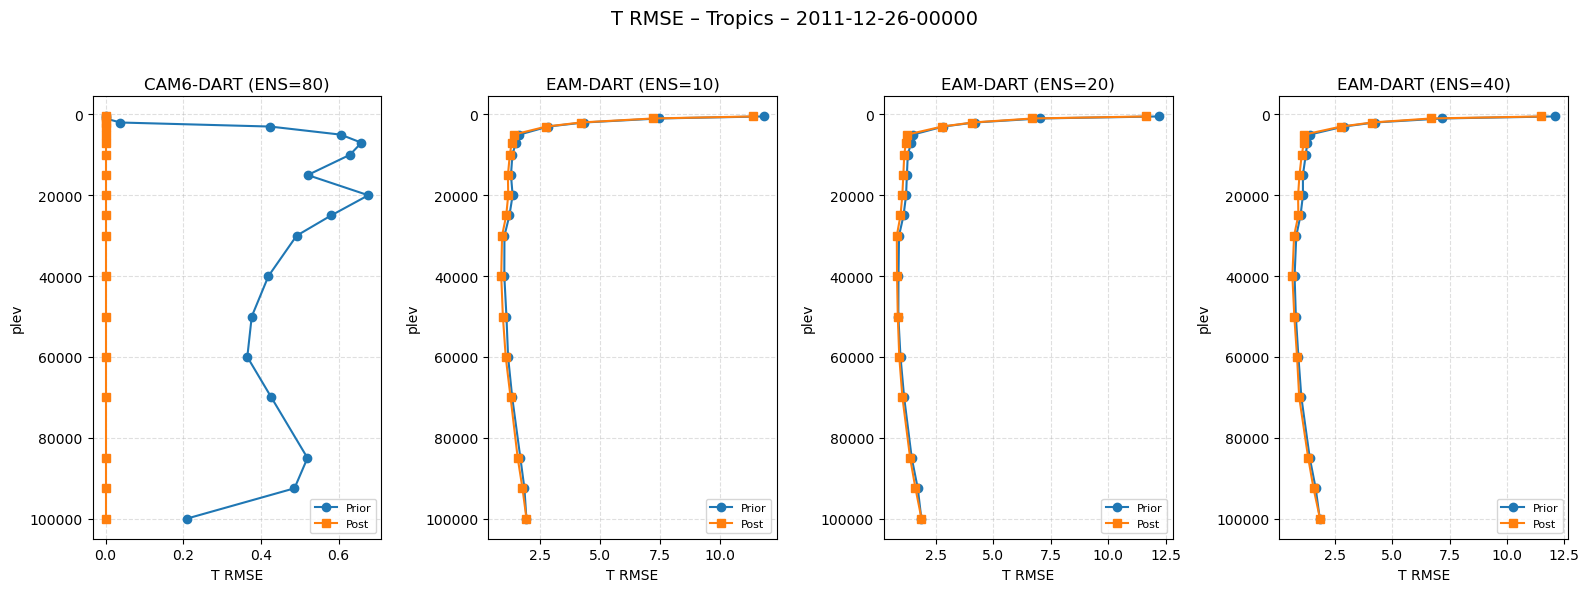

/tmp/ipykernel_378302/3104193788.py:465: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.88)  # a bit more room


RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

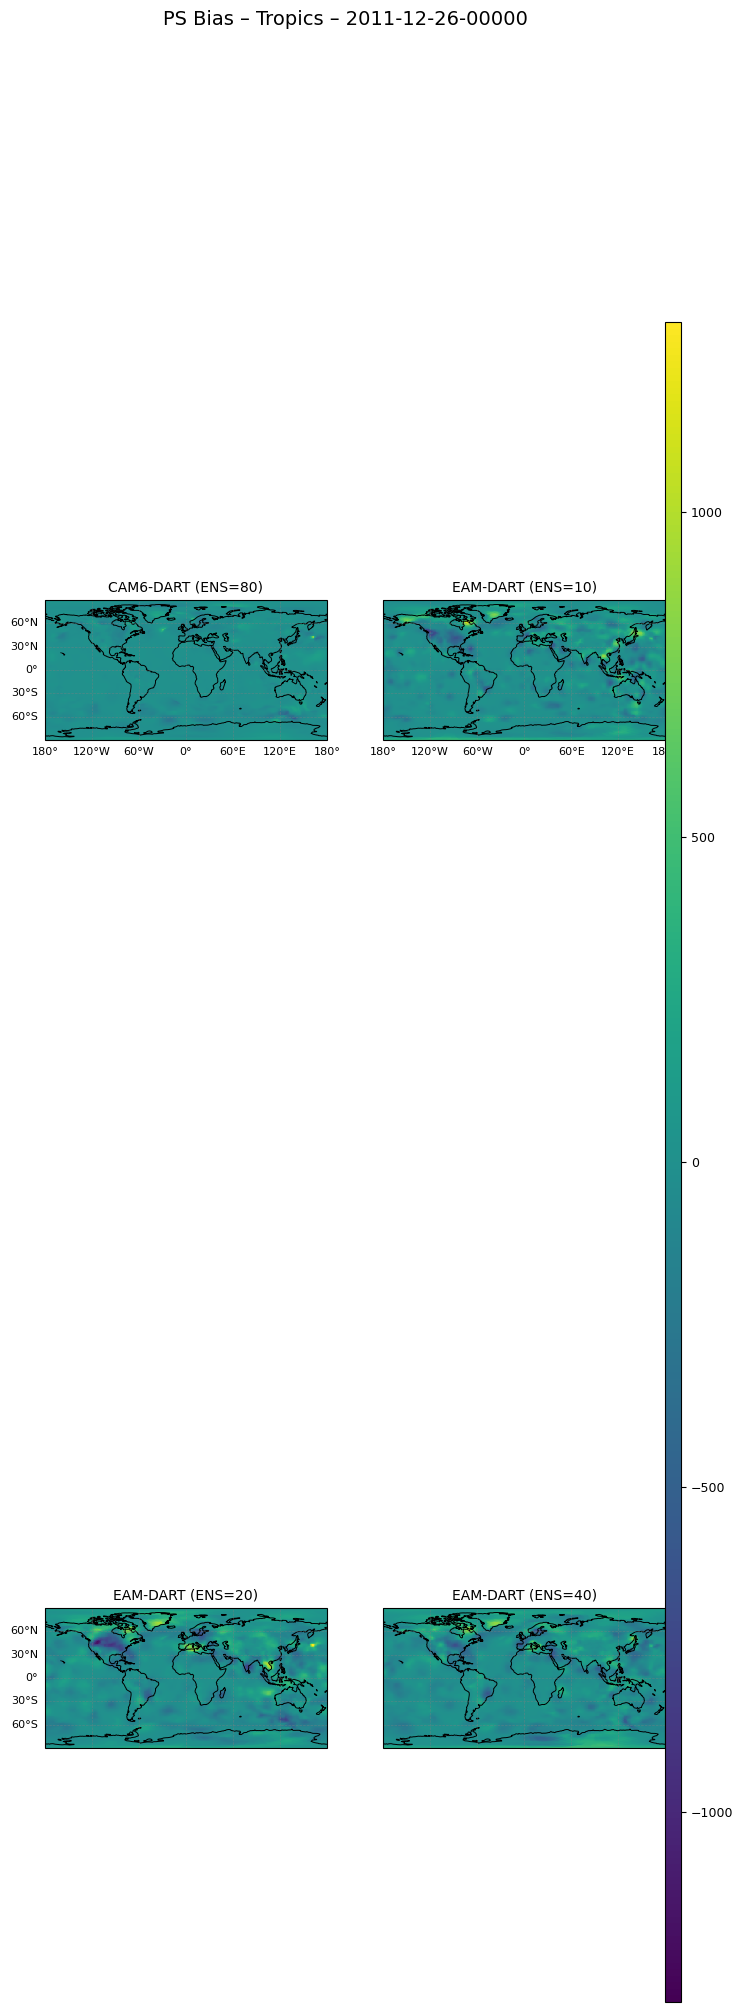

In [4]:
if __name__ == "__main__":
    # --- paths ---
    data_path = "/compyfs/zhan391/v3_dart_cda_scratch"
    mod_path = f"{data_path}/diag_output/analysis_ic"  # root_dir for DartAssimOutput

    freq = "monthly"
    component = "atm"
    run_seg = "da"
    obs_path = f"{data_path}/obs_data/{freq}"

    # Build experiments (still useful elsewhere)
    exp_dict: Dict[str, dict] = extract_exp_info(data_path)

    # pretty labels (optional; not used for indexing)
    model_label_map = {
        "CAM6-S0":          "CAM6-DART (ENS=80)",
        "CTRL10-S0":        "CTRL (ENS=10)",
        "DART10-S0":        "EAM-DART (ENS=10)",
        "DART20-S0":        "EAM-DART (ENS=20)",
        "DART40-S0":        "EAM-DART (ENS=40)",
        "DART40INF0p6-S0":  "EAM-DART (ENS=40, INF=0.6)",
    }

    var_dict = {
        "U": {"alias": "U", "unit": "m s$^{-1}$", "fact": 1,
              "level": np.linspace(-10, 10, 51), "comp": "atm", "ref": "CERES-OAFlux"},
        "V": {"alias": "V", "unit": "m s$^{-1}$", "fact": 1,
              "level": np.linspace(-2, 2, 51), "comp": "atm", "ref": "GPCP"},
        "T": {"alias": "T", "unit": "K", "fact": 1,
              "level": np.linspace(-10, 10, 51), "comp": "atm", "ref": "ERA5"},
        "Q": {"alias": "Q", "unit": "g kg$^{-1}$", "fact": 1000,
              "level": np.linspace(-8, 8, 51), "comp": "atm", "ref": "ERA5"},
        "PS": {"alias": "PS", "unit": "hPa", "fact": 1e-2,
               "level": np.linspace(-8, 8, 51), "comp": "atm", "ref": "ERA5"},
        "CLDLIQ": {"alias": "CLDLIQ", "unit": "g kg$^{-1}$", "fact": 1000,
                   "level": np.linspace(-10, 10, 51), "comp": "atm", "ref": "ERA5"},
        "CLDICE": {"alias": "CLDICE", "unit": "g kg$^{-1}$","fact": 1000,
                   "level": np.linspace(-10, 10, 51), "comp": "atm", "ref": "ERA5"},
    }

    experiments = [
        "CAM6-S0",
        "DART10-S0",
        "DART20-S0",
        "DART40-S0",
    ]
    
    timestamps = [
        "2011-12-26-00000",
        "2011-12-26-21600",
        "2011-12-26-43200",
        "2011-12-26-64800",
    ]

    ref_exp = "CAM6-S0"
    lat_range=(-90, 90)
    lon_range=(-180, 180)
    figsize = (8,24)
    
    for ts in timestamps:
        print(f"\n=== Analysis time {ts} ===")

        # build all DartAssimOutput objects for this time
        daos = {
            exp: DartAssimOutput.from_experiment(mod_path, exp, ts)
            for exp in experiments
        }
        ds = daos["CAM6-S0"].post_mean
        for d in ds.dims:
            if d.lower().startswith("lon"):
                print("LON DIM:", d)
                print("coords:", ds[d].values[:10])
            if d.lower().startswith("lat"):
                print("LAT DIM:", d)
                print("coords:", ds[d].values[:10])

        # reference: CAM6-S0 analysis
        ref_ds = daos[ref_exp].post_mean

        # 1) Multi-panel T RMSE profiles (tropics)
        DartAssimOutput.plot_profile(
            daos=daos,
            ref_ds=ref_ds,
            varname="T",
            metric="rmse",
            lat_range=lat_range,
            lon_range=lon_range,
            title_prefix=f"T RMSE – Tropics – {ts}",
            label_map=model_label_map,
        )

        # 2) Multi-panel PS bias maps (tropics)
        DartAssimOutput.plot_map(
            daos=daos,
            ref_ds=ref_ds,
            varname="PS",
            metric="increment",
            lat_range=lat_range,
            lon_range=lon_range,
            title_prefix=f"PS Bias – Tropics – {ts}",
            label_map=model_label_map,
            figsize=figsize
        )
